In [1]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully!")
print("Student ID: cit-24-01-0458")
print("Model: Long Short-Term Memory (LSTM)")

Mounted at /content/drive
Google Drive mounted successfully!
Student ID: cit-24-01-0458
Model: Long Short-Term Memory (LSTM)


In [2]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/data/clean_news_dataset.csv"

news_df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", news_df.shape)
print("Columns:", news_df.columns.tolist())

Dataset loaded successfully!
Shape: (39105, 8)
Columns: ['title', 'text', 'subject', 'date', 'label', 'content', 'text_length', 'clean_text']


In [3]:
print(news_df.isnull().sum())

print("\nLabel distribution:")
print(news_df["label"].value_counts())

title          0
text           0
subject        0
date           0
label          0
content        0
text_length    0
clean_text     5
dtype: int64

Label distribution:
label
1    21197
0    17908
Name: count, dtype: int64


In [4]:
news_df["clean_text"] = news_df["clean_text"].fillna("")

print("Missing clean_text values:", news_df["clean_text"].isnull().sum())

Missing clean_text values: 0


In [5]:
X = news_df["clean_text"]
y = news_df["label"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (39105,)
Target: (39105,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 31284
Testing samples: 7821


In [7]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 20000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 174140


In [8]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Training sequences:", len(X_train_seq))
print("Testing sequences:", len(X_test_seq))

Training sequences: 31284
Testing sequences: 7821


In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 500

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (31284, 500)
Testing shape: (7821, 500)


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 292s 651ms/step - accuracy: 0.5578 - loss: 0.6837 - val_accuracy: 0.5376 - val_loss: 0.6878
Epoch 2/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 288s 654ms/step - accuracy: 0.5351 - loss: 0.6841 - val_accuracy: 0.5436 - val_loss: 0.6464
Epoch 3/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 286s 650ms/step - accuracy: 0.6609 - loss: 0.5843 - val_accuracy: 0.9591 - val_loss: 0.2025
Epoch 4/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 288s 655ms/step - accuracy: 0.8276 - loss: 0.3904 - val_accuracy: 0.9789 - val_loss: 0.1804
Epoch 5/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 321s 652ms/step - accuracy: 0.9632 - loss: 0.1495 - val_accuracy: 0.9783 - val_loss: 0.0860
Epoch 6/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 325s 660ms/step - accuracy: 0.9866 - loss: 0.0625 - val_accuracy: 0.9811 - val_loss: 0.0622
Epoch 7/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 287s 651ms/step - accuracy: 0.9901 - loss: 0.0433 - val_accuracy: 0.9821 - val_loss: 0.0730
Epoch 8/10
440/440 ━━━━━━━━━━━━━━━━━━━━ 289s 658ms/step - accuracy: 0.9929 -

In [12]:
print("Training completed!")
print("Epochs completed:", len(history.history["loss"]))
print("Best validation accuracy:", max(history.history["val_accuracy"]))

Training completed!
Epochs completed: 8
Best validation accuracy: 0.9821029305458069


In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

245/245 ━━━━━━━━━━━━━━━━━━━━ 21s 85ms/step - accuracy: 0.9871 - loss: 0.0425
Test Loss: 0.0425168015062809
Test Accuracy: 0.9870860576629639


In [14]:
import numpy as np

y_prob = model.predict(X_test_pad)
y_pred = (y_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")
print("Predictions:", len(y_pred))

245/245 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step
Predictions generated successfully!
Predictions: 7821


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9870860503771897
Precision: 0.9847703842549204
Recall: 0.9915074309978769
F1 Score: 0.9881274244739626


[[3517   65]
 [  36 4203]]


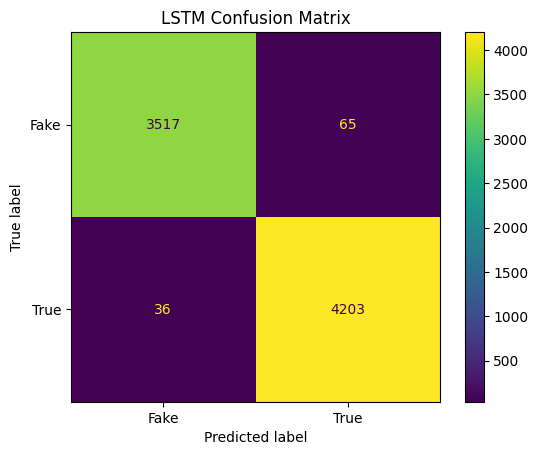

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)

disp.plot()
plt.title("LSTM Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "True"]
))

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      3582
        True       0.98      0.99      0.99      4239

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [18]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9978910172998093


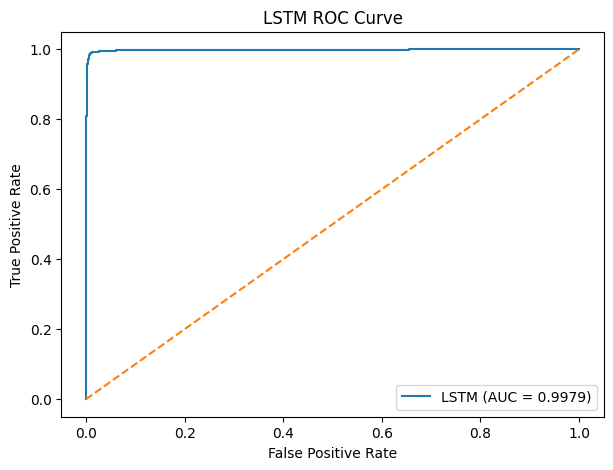

In [19]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"LSTM (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM ROC Curve")
plt.legend()
plt.show()

In [20]:
import os

MODEL_DIR = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/models"

os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, "lstm_model.keras")

model.save(model_path)

print("LSTM model saved successfully!")
print("Saved to:", model_path)

LSTM model saved successfully!
Saved to: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/models/lstm_model.keras


In [21]:
import joblib

tokenizer_path = os.path.join(MODEL_DIR, "lstm_tokenizer.pkl")

joblib.dump(tokenizer, tokenizer_path)

print("Tokenizer saved successfully!")
print("Saved to:", tokenizer_path)

Tokenizer saved successfully!
Saved to: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/models/lstm_tokenizer.pkl


In [22]:
results = {
    "Model": "LSTM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

results_df = pd.DataFrame([results])

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LSTM,0.987086,0.98477,0.991507,0.988127,0.997891


In [23]:
RESULTS_DIR = "/content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/results"

os.makedirs(RESULTS_DIR, exist_ok=True)

results_path = os.path.join(RESULTS_DIR, "lstm_results.csv")

results_df.to_csv(results_path, index=False)

print("Results saved successfully!")
print("Saved to:", results_path)

Results saved successfully!
Saved to: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/results/lstm_results.csv


In [24]:
from tensorflow.keras.models import load_model
import joblib

loaded_model = load_model(model_path)
loaded_tokenizer = joblib.load(tokenizer_path)

sample_text = X_test.iloc[0]

sample_sequence = loaded_tokenizer.texts_to_sequences([sample_text])
sample_padded = pad_sequences(
    sample_sequence,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

sample_probability = loaded_model.predict(sample_padded)[0][0]
sample_prediction = int(sample_probability >= 0.5)
sample_actual = int(y_test.iloc[0])

print("Actual Label:", sample_actual)
print("Predicted Label:", sample_prediction)
print("Prediction Probability:", sample_probability)
print("Saved model verification successful!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step
Actual Label: 0
Predicted Label: 0
Prediction Probability: 0.005227768
Saved model verification successful!


In [25]:
print("Dataset shape:", news_df.shape)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Vocabulary size:", MAX_WORDS)
print("Sequence length:", MAX_LEN)
print("Model:", "LSTM")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", roc_auc)
print("Model path:", model_path)
print("Tokenizer path:", tokenizer_path)
print("Results path:", results_path)

Dataset shape: (39105, 8)
Training samples: 31284
Testing samples: 7821
Vocabulary size: 20000
Sequence length: 500
Model: LSTM
Accuracy: 0.9870860503771897
Precision: 0.9847703842549204
Recall: 0.9915074309978769
F1 Score: 0.9881274244739626
ROC-AUC: 0.9978910172998093
Model path: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/models/lstm_model.keras
Tokenizer path: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/models/lstm_tokenizer.pkl
Results path: /content/drive/MyDrive/NLP_Fake_News_Detection/cit-24-01-0458/results/lstm_results.csv


In [26]:
comparison = pd.DataFrame({
    "Model": ["SVM", "LSTM"],
    "Type": ["Machine Learning", "Deep Learning"],
    "Accuracy": [0.9937348165, accuracy],
    "Precision": [0.9924776681, precision],
    "Recall": [0.9959896202, recall],
    "F1 Score": [0.9942305428, f1],
    "ROC-AUC": [0.9992993328, roc_auc]
})

display(comparison)

,Model,Type,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,Machine Learning,0.993735,0.992478,0.995990,0.994231,0.999299
1,LSTM,Deep Learning,0.987086,0.984770,0.991507,0.988127,0.997891
